# Project 2 - Sales Analysis - Machine Learning

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Create machine learning model to predict new hypothesis data
- Show plots to attempt to answer new hypothesis


## Inputs

CSV files used:

Sales_Combined_DataSet_Visualization.csv


## Outputs

Pipeline for use in streamlit 
Plots to show the data and attempt to answer the hypothesis


## Additional Comments

- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [1]:
%matplotlib inline

#iimport libraries
import os
import streamlit as st
import pandas as pd
import seaborn as sns
import plotly.express as px
import pathlib
import scipy.stats as stats
import matplotlib.pyplot as plt
import nbformat
from matplotlib.ticker import MultipleLocator

#for ML experiments
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve,
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
#from pyexpat import features

#for creating the pipeline file needed by streamlit/Heroku
import joblib

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT


# Hypothesis Being Tested

- What are the predicted sales for store types by month for next year?
- What are the predicted sales for stores in areas of high unemployment by month for next year?

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [2]:
#DataFrame vars for visualisation
dfSalesDataML = None
dfSalesDataML_Work = None
dfTempML = None


#other vars
intYear = 0
fig = None
ax = None
intNum = 0
dictDataFrames = dict()
objPipeline = None
objModel = None
X = None
X_Const = None
y = None


## Set Current Directory To Base Project Directory

In [3]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_Combined_DataSet_Work

In [4]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
#open into DataFrame which can be re-used during visualisations for filtering etc
dfSalesDataML = dictDataFrames["Sales_Combined_DataSet_Visualisation.csv"]

4 csv Files Read Into DataFrames

DataFrames Created:
Sales_Combined_DataSet_Visualisation.csv
Features_DataSet_Visualisation.csv
Sales_DataSet_Visualisation.csv
Stores_DataSet_Visualisation.csv




## Transform Date Column To Datetime Format

In [5]:

#transform Date to datetime
dfSalesDataML["Date"] = pd.to_datetime(dfSalesDataML["Date"], format="%d/%m/%Y")

#check schema
dfSalesDataML.dtypes

#create a working copy of the base DataFrame
dfSalesDataML_Work = dfSalesDataML.copy()

# Feature Engineering

Add new columns:

- Month  (numeric)
- Year   (numeric)


In [6]:
#create new columns
#["Month"] = dSalesDataML["Date"].dt.month
#dfSalesDataML["Year"] = dSalesDataML["Date"].dt.year


# Initailise Work DataFrame

In [7]:
#setup work DataFrame
dfSalesDataML_Work = dfSalesDataML.copy() 


# Linear Regression Model - Hypothesis 12

What are the predicted sales for store types by month for next year?

Store Type 1
Coefficient: [   87907.88785759 -1887083.58007374  2330210.38696529]
Intercept: 129853445.16763963
Store Type 2
Coefficient: [  -17464.64365558 -1103299.48780528  1679791.49918886]
Intercept: 61080727.602221765
Store Type 3
Coefficient: [  28332.74126094     341.9411674  -142004.16832958]
Intercept: 11766239.897825412
[11 12  1  2  3  4  5  6  7  8  9 10]


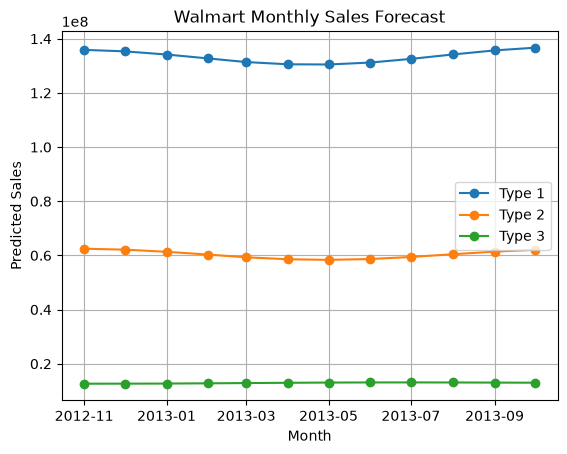


Store Type 1
MAE:  16,479,566.32
RMSE: 21,362,536.09
R²:   -0.043

Store Type 2
MAE:  8,081,705.18
RMSE: 11,689,758.46
R²:   -0.105

Store Type 3
MAE:  1,014,661.68
RMSE: 1,367,605.48
R²:   -0.182


In [47]:
#create the linear regression model for the hypothesis

#sort by date
dfSalesDataML_Work = dfSalesDataML.sort_values(by="Date")


monthly = (
    dfSalesDataML_Work.groupby([
        pd.Grouper(key="Date", freq="MS"),
        "Store_Type"
    ])["Weekly_Sales"]
    .sum()
    .reset_index()
)

monthly.rename(columns={"Weekly_Sales": "Monthly_Sales"}, inplace=True)

#print(monthly.head())



monthly["Year"] = monthly["Date"].dt.year
monthly["Month"] = monthly["Date"].dt.month

# Continuous time index
monthly["Time"] = (
    (monthly["Year"] - monthly["Year"].min()) * 12
    + monthly["Month"]
)

# Seasonal features
monthly["Month_Sin"] = np.sin(2 * np.pi * monthly["Month"] / 12)
monthly["Month_Cos"] = np.cos(2 * np.pi * monthly["Month"] / 12)

##print(monthly.tail(15))
#print(monthly.head())





models = {}

features = [
    "Time",
    "Month_Sin",
    "Month_Cos"
]

for store_type in monthly["Store_Type"].unique():

    data = monthly[monthly["Store_Type"] == store_type]

    X = data[features]
    y = data["Monthly_Sales"]

    model = LinearRegression()
    model.fit(X, y)

    models[store_type] = model

    print(f"Store Type {store_type}")
    print(f"Coefficient: {model.coef_}")
    print(f"Intercept: {model.intercept_}")
    
    last_date = monthly["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

future = pd.DataFrame({"Date": future_dates})

future["Year"] = future["Date"].dt.year
future["Month"] = future["Date"].dt.month

future["Time"] = (
    (future["Year"] - monthly["Year"].min()) * 12
    + future["Month"]
)

future["Month_Sin"] = np.sin(
    2 * np.pi * future["Month"] / 12
)

future["Month_Cos"] = np.cos(
    2 * np.pi * future["Month"] / 12
)


predictions = []

for store_type, model in models.items():

    X_future = future[features]

    predicted_sales = model.predict(X_future)

    temp = future[["Date"]].copy()
    temp["Store_Type"] = store_type
    temp["Predicted_Sales"] = predicted_sales

    predictions.append(temp)

forecast = pd.concat(predictions, ignore_index=True)

#print(forecast)

print(forecast["Date"].dt.month.unique())


# plt.figure(figsize=(12, 6))

for store_type in forecast["Store_Type"].unique():

    data = forecast[forecast["Store_Type"] == store_type]

    plt.plot(
        data["Date"],
        data["Predicted_Sales"],
        marker="o",
        label=f"Type {store_type}"
    )


plt.title("Walmart Monthly Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.show()




for store_type in monthly["Store_Type"].unique():

    data = monthly[monthly["Store_Type"] == store_type].copy()

    # Last 12 months as test data
    train = data.iloc[:-12]
    test = data.iloc[-12:]

    model = LinearRegression()

    model.fit(train[features], train["Monthly_Sales"])

    predictions = model.predict(test[features])

    mae = mean_absolute_error(
        test["Monthly_Sales"],
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            test["Monthly_Sales"],
            predictions
        )
    )

    r2 = r2_score(
        test["Monthly_Sales"],
        predictions
    )

    print(f"\nStore Type {store_type}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.3f}")
    
    
    

#One important consideration: a basic linear regression probably won't be the best forecasting model for Walmart sales. 
#Sales have strong seasonality, holidays, trends, and differences between individual stores. If this is for a coursework/project, 
#the linear regression above is a good starting point, but you could improve it substantially by adding holiday indicators, 
#lagged sales, store-level information, and seasonal variables.

#If your assignment specifically requires linear regression, I'd use the model above and explain Time, Month_Sin, and Month_Cos 
#as the independent variables and Monthly_Sales as the dependent variable.



    
    


# Linear Regression Model - Hypothesis 13

In [48]:


# ============================================================
# 2. CONVERT DATE
# ============================================================

# Walmart dataset dates are in US format in the original dataset
# If your CSV contains dates such as 26/07/2013, use dayfirst=True.
dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML_Work["Date"],
    dayfirst=True,
    errors="coerce"
)


# Remove rows where the date could not be converted
dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features
dfSalesDataML_Work["MonthSin"] = np.sin(2 * np.pi * dfSalesDataML_Work["Month"] / 12)
dfSalesDataML_Work["MonthCos"] = np.cos(2 * np.pi * dfSalesDataML_Work["Month"] / 12)

# Convert boolean to integer
dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. CREATE TRAIN / TEST DATA
# ============================================================

# IMPORTANT:
# 2012 is the test year.
# 2013 is NOT used as the test set.

train_df = dfSalesDataML_Work[dfSalesDataML_Work["Year"] < 2012].copy()
test_df = dfSalesDataML_Work[dfSalesDataML_Work["Year"] == 2012].copy()


print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print(
    "Training date range:",
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print(
    "Testing date range:",
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

TARGET = "Weekly_Sales"


X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]


# ============================================================
# 6. PREPROCESSING
# ============================================================

numeric_features = [
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

categorical_features = [
    "Store",
    "Dept"
]


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 7. CREATE LINEAR REGRESSION PIPELINE
# ============================================================

model = LinearRegression()


pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


# ============================================================
# 8. TRAIN
# ============================================================

print("\nTraining Linear Regression...")

pipeline.fit(X_train, y_train)


# ============================================================
# 9. PREDICT
# ============================================================

y_pred = pipeline.predict(X_test)


# ============================================================
# 10. EVALUATE
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


print("\n==============================")
print("LINEAR REGRESSION RESULTS")
print("==============================")

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")


# ============================================================
# 11. SAVE PIPELINE
# ============================================================

MODEL_PATH = "linear_regression_pipeline.pkl"

joblib.dump(
    pipeline,
    MODEL_PATH
)

print("\nPipeline saved to:")
print(MODEL_PATH)









Training rows: 294132
Testing rows: 127438
Training date range: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
Testing date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00

Training Linear Regression...

LINEAR REGRESSION RESULTS
MAE:  7,981.97
RMSE: 12,215.22
R²:   0.6951

Pipeline saved to:
linear_regression_pipeline.pkl


# Linear Regression Plot

Test year: 2012
Previous year: 2011
Test rows: 127438
Previous year rows: 153453

Plot data:
         Date  WeekOfYear  Actual_Sales  Predicted_Sales  Previous_Year_Sales
0  2012-01-06           1   44955421.95     3.983875e+07          42775787.77
1  2012-01-13           2   42023078.48     3.969133e+07          40673678.04
2  2012-01-20           3   42080996.56     3.959689e+07          40654648.03
3  2012-01-27           4   39834974.67     3.946888e+07          39599852.99
4  2012-02-03           5   46085608.09     4.646054e+07          46153111.12
5  2012-02-10           6   50009407.92     4.716707e+07          47336192.79
6  2012-02-17           7   50197056.96     4.624761e+07          48716164.12
7  2012-02-24           8   45771506.57     4.594901e+07          44125859.84
8  2012-03-02           9   46861034.97     4.751261e+07          46980603.74
9  2012-03-09          10   47480454.11     4.750276e+07          44627319.40
10 2012-03-16          11   46901504.94     4.730

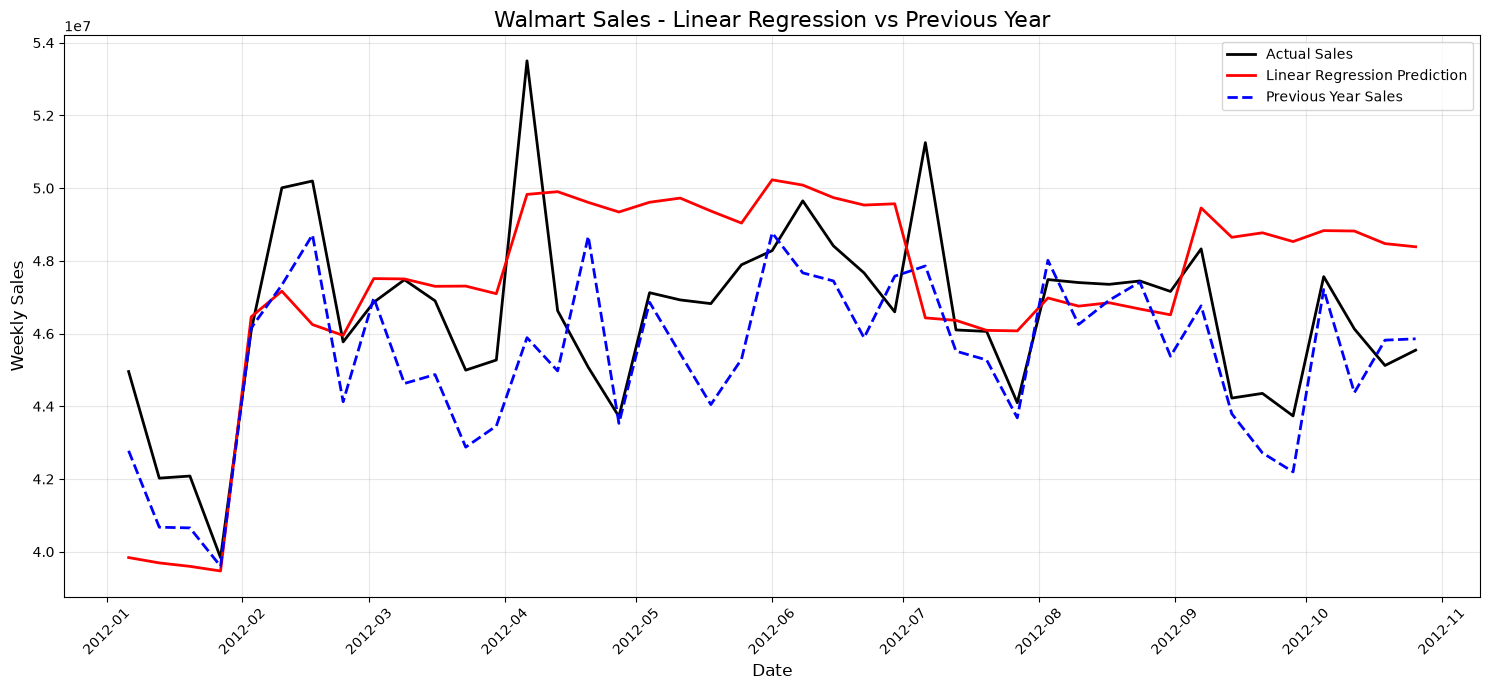

In [49]:

# ============================================================
# 2. CONVERT DATE
# ============================================================

dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML_Work["Date"],
    dayfirst=True,
    errors="coerce"
)

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work    ["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. LOAD LINEAR REGRESSION PIPELINE
# ============================================================

MODEL_PATH = "linear_regression_pipeline.pkl"

pipeline = joblib.load(MODEL_PATH)


# ============================================================
# 5. SELECT TEST AND PREVIOUS YEAR
# ============================================================

TEST_YEAR = 2012
PREVIOUS_YEAR = TEST_YEAR - 1

test_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == TEST_YEAR
].copy()

previous_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == PREVIOUS_YEAR
].copy()


print("Test year:", TEST_YEAR)
print("Previous year:", PREVIOUS_YEAR)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Previous year rows:",
    len(previous_df)
)


# ============================================================
# 6. FEATURES
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]


# ============================================================
# 7. GENERATE MODEL PREDICTIONS
# ============================================================

X_test = test_df[FEATURES]

test_df["Predicted_Sales"] = pipeline.predict(
    X_test
)


# ============================================================
# 8. ACTUAL 2012 SALES BY WEEK
# ============================================================

actual_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear"]
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

actual_sales = actual_sales.rename(
    columns={
        "Weekly_Sales": "Actual_Sales"
    }
)


# ============================================================
# 9. PREDICTED 2012 SALES BY WEEK
# ============================================================

predicted_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 10. PREVIOUS YEAR SALES BY WEEK
# ============================================================

previous_sales = (
    previous_df
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

previous_sales = previous_sales.rename(
    columns={
        "Weekly_Sales": "Previous_Year_Sales"
    }
)


# ============================================================
# 11. MERGE ACTUAL AND PREDICTED
# ============================================================

plot_df = actual_sales.merge(
    predicted_sales,
    on=["Date", "WeekOfYear"],
    how="left"
)


# ============================================================
# 12. MERGE PREVIOUS YEAR
# ============================================================

plot_df = plot_df.merge(
    previous_sales,
    on="WeekOfYear",
    how="left"
)


# Sort chronologically

plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# 13. CHECK THE DATA
# ============================================================

print("\nPlot data:")

print(
    plot_df[
        [
            "Date",
            "WeekOfYear",
            "Actual_Sales",
            "Predicted_Sales",
            "Previous_Year_Sales"
        ]
    ].head(20)
)


# Check for missing previous year values

missing_previous = plot_df[
    "Previous_Year_Sales"
].isna().sum()

print(
    "\nMissing previous-year values:",
    missing_previous
)


# ============================================================
# 14. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Actual sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Actual_Sales"],
    label="Actual Sales",
    color="black",
    linewidth=2
)


# ------------------------------------------------------------
# Linear Regression predictions
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    label="Linear Regression Prediction",
    color="red",
    linewidth=2
)


# ------------------------------------------------------------
# Previous year sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Previous_Year_Sales"],
    label="Previous Year Sales",
    color="blue",
    linestyle="--",
    linewidth=2
)


# ============================================================
# 15. FORMAT GRAPH
# ============================================================

plt.title(
    "Walmart Sales - Linear Regression vs Previous Year",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Weekly Sales",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 16. SAVE GRAPH
# ============================================================

plt.savefig(
    "linear_regression_sales_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 17. SHOW GRAPH
# ============================================================

plt.show()

# Random Forest

In [50]:

# ============================================================
# 2. CONVERT DATE
# ============================================================

# Use dayfirst=True if your dates are written:
#
# 26/07/2013
#
# rather than:
#
# 07/26/2013

dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML_Work["Date"],
    dayfirst=True,
    errors="coerce"
)

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work            ["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. CREATE TRAIN / TEST DATA
# ============================================================

# Training:
# All years before 2012
#
# Testing:
# 2012 only
#
# 2013 is deliberately NOT used for testing.

train_df = dfSalesDataML_Work[dfSalesDataML_Work["Year"] < 2012].copy()

test_df = dfSalesDataML_Work[dfSalesDataML_Work["Year"] == 2012].copy()


print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print(
    "Training date range:",
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print(
    "Testing date range:",
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)


# ============================================================
# 5. FEATURES / TARGET
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

TARGET = "Weekly_Sales"


X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]


# ============================================================
# 6. PREPROCESSING
# ============================================================

numeric_features = [
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

categorical_features = [
    "Store",
    "Dept"
]


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)


categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 7. RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)


# ============================================================
# 8. CREATE PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)


# ============================================================
# 9. TRAIN
# ============================================================

print("\nTraining Random Forest...")

pipeline.fit(
    X_train,
    y_train
)


# ============================================================
# 10. PREDICT
# ============================================================

y_pred = pipeline.predict(X_test)


# ============================================================
# 11. EVALUATE
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n==============================")
print("RANDOM FOREST RESULTS")
print("==============================")

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")


# ============================================================
# 12. SAVE PIPELINE
# ============================================================

MODEL_PATH = "random_forest_pipeline.pkl"

joblib.dump(
    pipeline,
    MODEL_PATH
)

print("\nPipeline saved to:")
print(MODEL_PATH)

Training rows: 294132
Testing rows: 127438
Training date range: 2010-02-05 00:00:00 to 2011-12-30 00:00:00
Testing date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00

Training Random Forest...

RANDOM FOREST RESULTS
MAE:  7,429.73
RMSE: 10,070.99
R²:   0.7927

Pipeline saved to:
random_forest_pipeline.pkl


In [51]:
# Random Forest - Plot

Test year: 2012
Previous year: 2011
Test rows: 127438
Previous year rows: 153453

Plot data:
         Date  WeekOfYear  Actual_Sales  Predicted_Sales  Previous_Year_Sales
0  2012-01-06           1   44955421.95     4.696554e+07          42775787.77
1  2012-01-13           2   42023078.48     4.651213e+07          40673678.04
2  2012-01-20           3   42080996.56     4.629591e+07          40654648.03
3  2012-01-27           4   39834974.67     4.590798e+07          39599852.99
4  2012-02-03           5   46085608.09     4.816303e+07          46153111.12
5  2012-02-10           6   50009407.92     4.834976e+07          47336192.79
6  2012-02-17           7   50197056.96     4.807020e+07          48716164.12
7  2012-02-24           8   45771506.57     4.715775e+07          44125859.84
8  2012-03-02           9   46861034.97     4.777463e+07          46980603.74
9  2012-03-09          10   47480454.11     4.752807e+07          44627319.40
10 2012-03-16          11   46901504.94     4.660

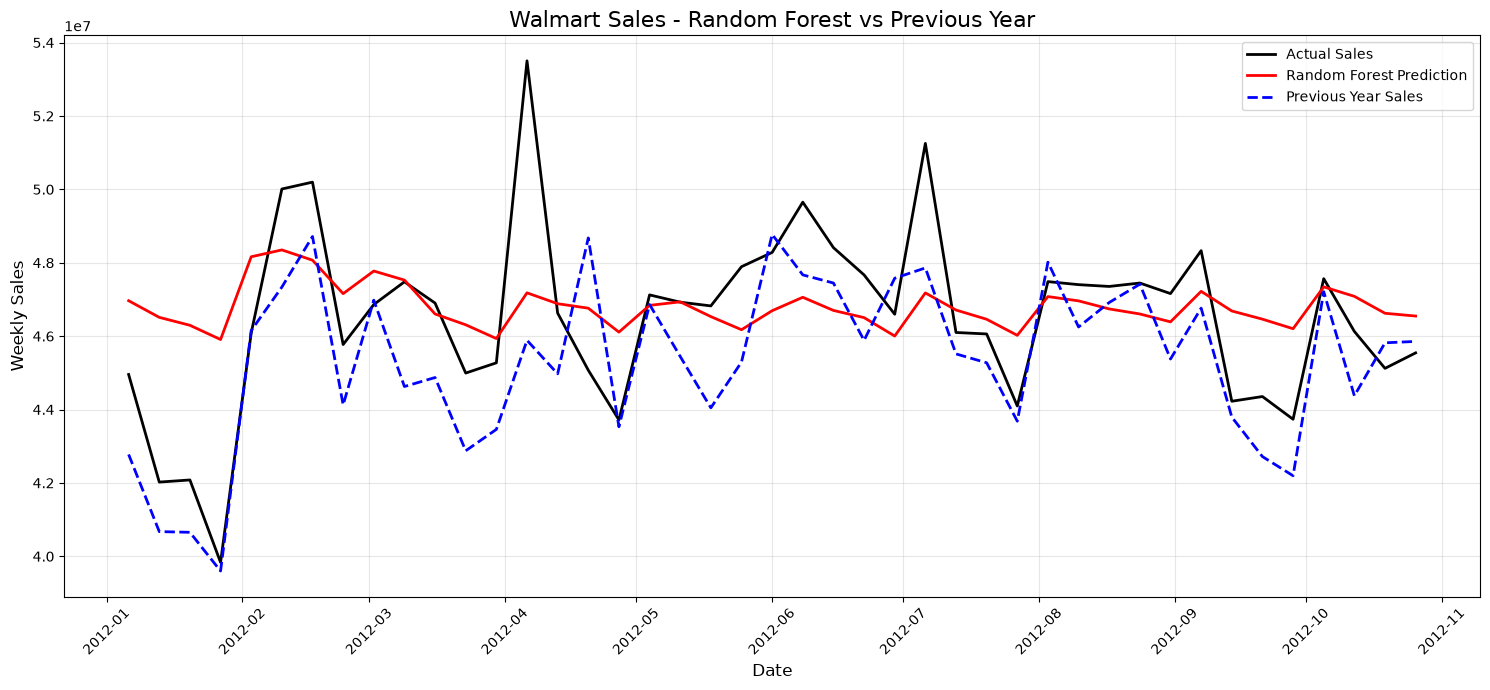

In [52]:

# ============================================================
# 2. CONVERT DATE
# ============================================================

dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML_Work["Date"],
    dayfirst=True,
    errors="coerce"
)

dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek
dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# Cyclical month features

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)


# ============================================================
# 4. LOAD RANDOM FOREST PIPELINE
# ============================================================

MODEL_PATH = "random_forest_pipeline.pkl"

pipeline = joblib.load(MODEL_PATH)


# ============================================================
# 5. SELECT TEST AND PREVIOUS YEAR
# ============================================================

TEST_YEAR = 2012
PREVIOUS_YEAR = TEST_YEAR - 1

test_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == TEST_YEAR
].copy()

previous_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == PREVIOUS_YEAR
].copy()


print("Test year:", TEST_YEAR)
print("Previous year:", PREVIOUS_YEAR)

print(
    "Test rows:",
    len(test_df)
)

print(
    "Previous year rows:",
    len(previous_df)
)


# ============================================================
# 6. FEATURES
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]


# ============================================================
# 7. GENERATE RANDOM FOREST PREDICTIONS
# ============================================================

X_test = test_df[FEATURES]

test_df["Predicted_Sales"] = pipeline.predict(
    X_test
)


# ============================================================
# 8. ACTUAL 2012 SALES BY WEEK
# ============================================================

actual_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear"]
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

actual_sales = actual_sales.rename(
    columns={
        "Weekly_Sales": "Actual_Sales"
    }
)


# ============================================================
# 9. PREDICTED 2012 SALES BY WEEK
# ============================================================

predicted_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 10. PREVIOUS YEAR SALES BY WEEK
# ============================================================

previous_sales = (
    previous_df
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

previous_sales = previous_sales.rename(
    columns={
        "Weekly_Sales": "Previous_Year_Sales"
    }
)


# ============================================================
# 11. MERGE ACTUAL AND PREDICTED SALES
# ============================================================

plot_df = actual_sales.merge(
    predicted_sales,
    on=["Date", "WeekOfYear"],
    how="left"
)


# ============================================================
# 12. MERGE PREVIOUS YEAR SALES
# ============================================================

plot_df = plot_df.merge(
    previous_sales,
    on="WeekOfYear",
    how="left"
)


# Sort by date

plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# 13. CHECK DATA
# ============================================================

print("\nPlot data:")

print(
    plot_df[
        [
            "Date",
            "WeekOfYear",
            "Actual_Sales",
            "Predicted_Sales",
            "Previous_Year_Sales"
        ]
    ].head(20)
)


# Check missing previous-year values

missing_previous = (
    plot_df["Previous_Year_Sales"]
    .isna()
    .sum()
)

print(
    "\nMissing previous-year values:",
    missing_previous
)


# ============================================================
# 14. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Actual sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Actual_Sales"],
    label="Actual Sales",
    color="black",
    linewidth=2
)


# ------------------------------------------------------------
# Random Forest predictions
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    label="Random Forest Prediction",
    color="red",
    linewidth=2
)


# ------------------------------------------------------------
# Previous year sales
# ------------------------------------------------------------

plt.plot(
    plot_df["Date"],
    plot_df["Previous_Year_Sales"],
    label="Previous Year Sales",
    color="blue",
    linestyle="--",
    linewidth=2
)


# ============================================================
# 15. FORMAT GRAPH
# ============================================================

plt.title(
    "Walmart Sales - Random Forest vs Previous Year",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Weekly Sales",
    fontsize=12
)

plt.legend(
    loc="best"
)

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 16. SAVE GRAPH
# ============================================================

plt.savefig(
    "random_forest_sales_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 17. SHOW GRAPH
# ============================================================

plt.show()

# Linear Regression Model - Hypothesis 13

Predict 2013 Sales


Loading datasets...

Features:
(8190, 11)

Sales:
(421570, 6)

Stores:
(45, 4)

Features date range:
2010-01-10 00:00:00 to 2013-12-07 00:00:00

Sales date range:
2010-01-10 00:00:00 to 2012-12-10 00:00:00

Features + Stores: (3285, 14)

Training dataset: (168156, 17)

Forecast dataset: (42874, 15)

Forecast date range:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

Training Linear Regression...
Training complete.

Pipeline saved:
linear_regression_2013_pipeline.pkl

Generating 2013 predictions...

2013 prediction rows: 42874

2013 prediction period:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

Plot saved:
linear_regression_2013_forecast.png


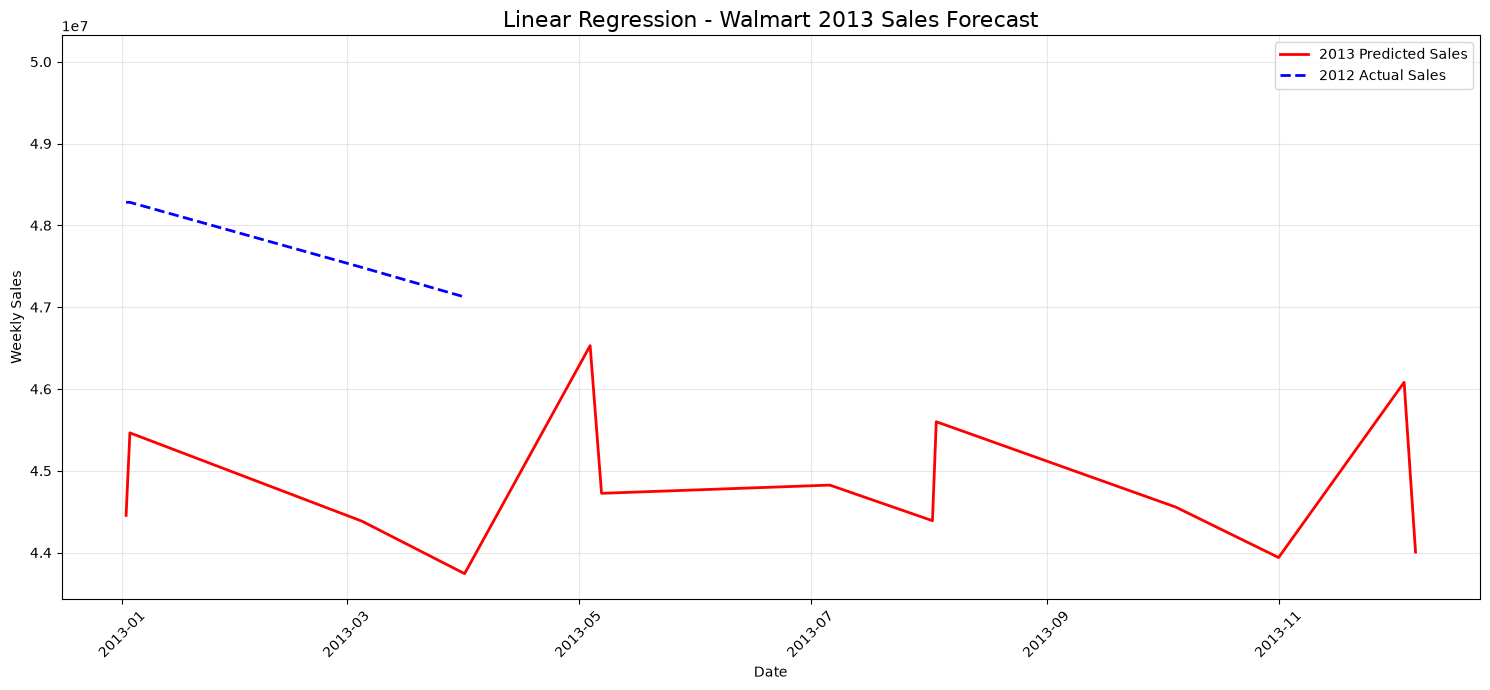

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression


# ============================================================
# 1. FILE PATHS
# ============================================================

# FEATURES_PATH = dictDataFrames["Features_DataSet_Visualisation.csv"]
# SALES_PATH = dictDataFrames["Sales_DataSet.csv"]
# STORES_PATH = dictDataFrames["Stores_DataSet.csv"]


features = dictDataFrames["Features_DataSet_Visualisation.csv"]
sales = dictDataFrames["Sales_DataSet_Visualisation.csv"]
stores = dictDataFrames["Stores_DataSet_Visualisation.csv"]

MODEL_PATH = "linear_regression_2013_pipeline.pkl"
PLOT_PATH = "linear_regression_2013_forecast.png"


# ============================================================
# 2. LOAD DATA
# ============================================================

print("Loading datasets...")

# features = pd.read_csv(
#     FEATURES_PATH
# )

# sales = pd.read_csv(
#     SALES_PATH
# )

# stores = pd.read_csv(
#     STORES_PATH
# )


print("\nFeatures:")
print(features.shape)

print("\nSales:")
print(sales.shape)

print("\nStores:")
print(stores.shape)


# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================

features.columns = (
    features.columns
    .str.strip()
)

sales.columns = (
    sales.columns
    .str.strip()
)

stores.columns = (
    stores.columns
    .str.strip()
)


# ============================================================
# 4. CONVERT DATES
# ============================================================

features["Date"] = pd.to_datetime(
    features["Date"],
    errors="coerce"
)

sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)


# Remove invalid dates

features = features.dropna(
    subset=["Date"]
)

sales = sales.dropna(
    subset=["Date"]
)


print("\nFeatures date range:")

print(
    features["Date"].min(),
    "to",
    features["Date"].max()
)


print("\nSales date range:")

print(
    sales["Date"].min(),
    "to",
    sales["Date"].max()
)


# ============================================================
# 5. MERGE FEATURES WITH STORES
# ============================================================

features_stores = features.merge(
    stores,
    on="Store",
    how="left"
)


print(
    "\nFeatures + Stores:",
    features_stores.shape
)


# ============================================================
# 6. CREATE TRAINING DATA
# ============================================================

# Sales contains the target Weekly_Sales.
#
# Merge sales with Features + Stores.
#
# Sales are at Store + Dept + Date level.
# Features are at Store + Date level.

training_df = sales.merge(
    features_stores,
    on=[
        "Store",
        "Date",
        "IsHoliday"
    ],
    how="left"
)


print(
    "\nTraining dataset:",
    training_df.shape
)


# ============================================================
# 7. CREATE FORECAST DATA
# ============================================================

# The features dataset contains dates beyond
# the sales dataset.
#
# We use these dates to predict future sales.

forecast_df = features_stores[
    features_stores["Date"] >
    sales["Date"].max()
].copy()


# We need predictions for every Store/Department
# combination that existed in the sales data.

store_depts = sales[
    ["Store", "Dept"]
].drop_duplicates()


forecast_df = forecast_df.merge(
    store_depts,
    on="Store",
    how="inner"
)


print(
    "\nForecast dataset:",
    forecast_df.shape
)


print(
    "\nForecast date range:"
)

print(
    forecast_df["Date"].min(),
    "to",
    forecast_df["Date"].max()
)


# ============================================================
# 8. FEATURE ENGINEERING FUNCTION
# ============================================================

def create_features(df):

    df = df.copy()

    # Date features

    df["Year"] = (
        df["Date"].dt.year
    )

    df["Month"] = (
        df["Date"].dt.month
    )

    df["Day"] = (
        df["Date"].dt.day
    )

    df["DayOfWeek"] = (
        df["Date"].dt.dayofweek
    )

    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["Quarter"] = (
        df["Date"].dt.quarter
    )

    # Cyclical features

    df["MonthSin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )

    df["MonthCos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )

    df["WeekSin"] = np.sin(
        2 * np.pi * df["WeekOfYear"] / 52
    )

    df["WeekCos"] = np.cos(
        2 * np.pi * df["WeekOfYear"] / 52
    )

    # Holiday

    df["IsHoliday"] = (
        df["IsHoliday"]
        .astype(int)
    )

    return df


training_df = create_features(
    training_df
)

forecast_df = create_features(
    forecast_df
)


# ============================================================
# 9. HANDLE MARKDOWN COLUMNS
# ============================================================

markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


for column in markdown_columns:

    if column in training_df.columns:

        training_df[column] = (
            training_df[column]
            .fillna(0)
        )

    if column in forecast_df.columns:

        forecast_df[column] = (
            forecast_df[column]
            .fillna(0)
        )


# ============================================================
# 10. FEATURES USED BY MODEL
# ============================================================

FEATURES = [

    # Store information
    "Store",
    "Dept",
    "Store_Type",
    "Size",

    # Date information
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    # Cyclical features
    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    # Holiday
    "IsHoliday",

    # Walmart economic features
    "Temperature",
    "Unemployment",

    # Markdown
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


TARGET = "Weekly_Sales"


# ============================================================
# 11. CHECK COLUMNS
# ============================================================

missing_columns = [
    column
    for column in FEATURES
    if column not in training_df.columns
]


if missing_columns:

    raise ValueError(
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 12. X AND Y
# ============================================================

X_train = training_df[
    FEATURES
]

y_train = training_df[
    TARGET
]

X_forecast = forecast_df[
    FEATURES
]


# ============================================================
# 13. PREPROCESSING
# ============================================================

numeric_features = [

    "Size",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    "IsHoliday",

    "Temperature",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


categorical_features = [
    "Store",
    "Dept",
    "Store_Type"
]


numeric_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 14. LINEAR REGRESSION
# ============================================================

model = LinearRegression()


pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )
    ]
)


# ============================================================
# 15. TRAIN
# ============================================================

print(
    "\nTraining Linear Regression..."
)

pipeline.fit(
    X_train,
    y_train
)

print(
    "Training complete."
)


# ============================================================
# 16. SAVE PIPELINE
# ============================================================

joblib.dump(
    pipeline,
    MODEL_PATH
)

print(
    "\nPipeline saved:"
)

print(
    MODEL_PATH
)


# ============================================================
# 17. PREDICT 2013
# ============================================================

print(
    "\nGenerating 2013 predictions..."
)

forecast_df["Predicted_Sales"] = (
    pipeline.predict(
        X_forecast
    )
)


# ============================================================
# 18. SELECT 2013
# ============================================================

forecast_2013 = forecast_df[
    forecast_df["Date"].dt.year == 2013
].copy()


print(
    "\n2013 prediction rows:",
    len(forecast_2013)
)


print(
    "\n2013 prediction period:"
)

print(
    forecast_2013["Date"].min(),
    "to",
    forecast_2013["Date"].max()
)


# ============================================================
# 19. AGGREGATE 2013 PREDICTIONS
# ============================================================

forecast_sales = (
    forecast_2013
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 20. GET 2012 ACTUAL SALES
# ============================================================

actual_2012 = training_df[
    training_df["Year"] == 2012
].copy()


sales_2012 = (
    actual_2012
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)


sales_2012 = sales_2012.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)


# ============================================================
# 21. MERGE FOR PLOT
# ============================================================

plot_df = forecast_sales.merge(
    sales_2012,
    on="WeekOfYear",
    how="left"
)


plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# 22. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    color="red",
    linewidth=2,
    label="2013 Predicted Sales"
)


# plt.plot(
#     plot_df["Date"],
#     plot_df["Previous_Year_Sales"],
#     color="blue",
#     linestyle="--",
#     linewidth=2,
#     label="2012 Actual Sales"
# )


plt.title(
    "Linear Regression - Walmart 2013 Sales Forecast",
    fontsize=16
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Weekly Sales"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 23. SAVE PLOT
# ============================================================

plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\nPlot saved:"
)

print(
    PLOT_PATH
)


plt.show()

# Random Forest Model - 2013

Loading datasets...

Sales: 2010-01-10 00:00:00 to 2012-12-10 00:00:00
Features: 2010-01-10 00:00:00 to 2013-12-07 00:00:00

Training rows: 168156
Forecast rows: 42874

Training Random Forest...
Training complete.

Pipeline saved:
random_forest_2013_pipeline.pkl

Generating predictions...

2013 rows: 42874
2013 period:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

Plot saved:
random_forest_2013_forecast.png


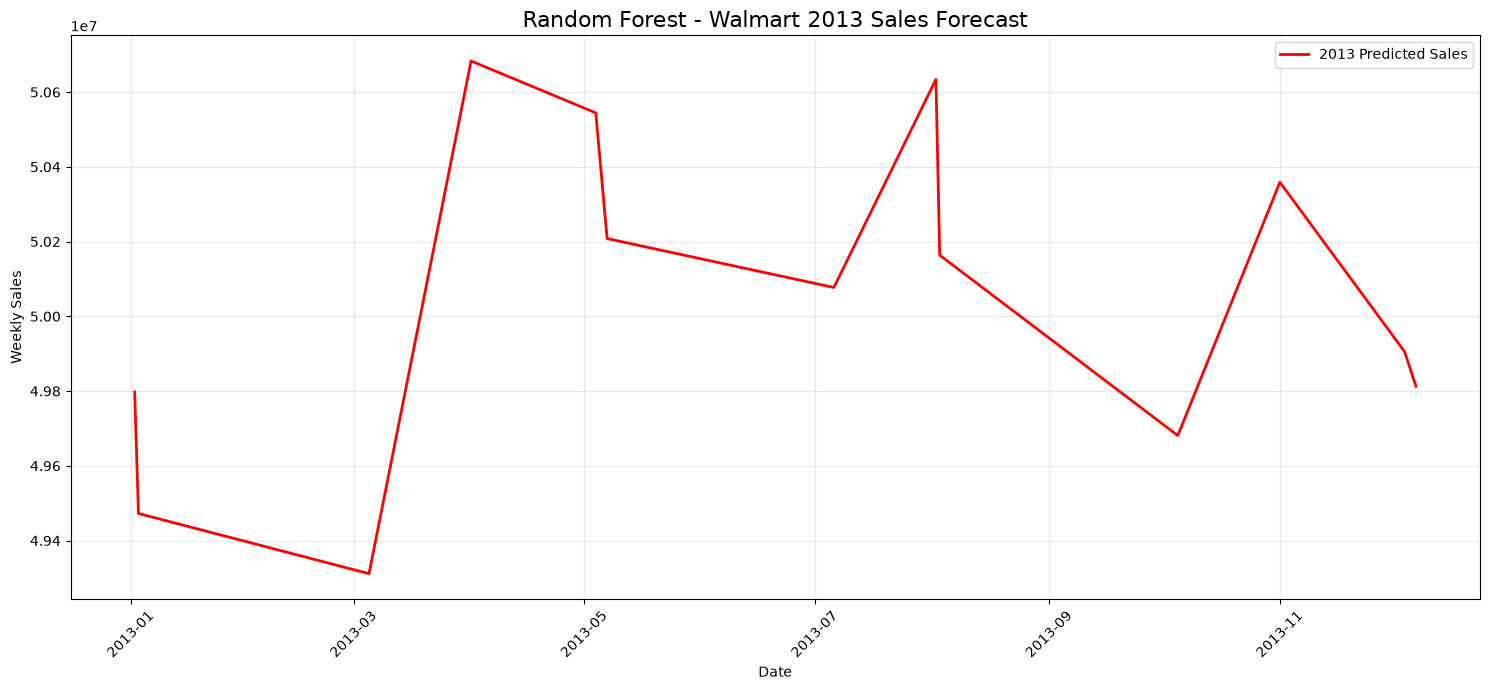

In [13]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor


# ============================================================
# FILES
# ============================================================

features = dictDataFrames["Features_DataSet_Visualisation.csv"]
sales = dictDataFrames["Sales_DataSet_Visualisation.csv"]
stores = dictDataFrames["Stores_DataSet_Visualisation.csv"]

MODEL_PATH = "random_forest_2013_pipeline.pkl"
PLOT_PATH = "random_forest_2013_forecast.png"


# ============================================================
# LOAD
# ============================================================

print("Loading datasets...")


features.columns = (
    features.columns.str.strip()
)

sales.columns = (
    sales.columns.str.strip()
)

stores.columns = (
    stores.columns.str.strip()
)


# ============================================================
# DATES
# ============================================================

features["Date"] = pd.to_datetime(
    features["Date"],
    errors="coerce"
)

sales["Date"] = pd.to_datetime(
    sales["Date"],
    errors="coerce"
)


features = features.dropna(
    subset=["Date"]
)

sales = sales.dropna(
    subset=["Date"]
)


print(
    "\nSales:",
    sales["Date"].min(),
    "to",
    sales["Date"].max()
)

print(
    "Features:",
    features["Date"].min(),
    "to",
    features["Date"].max()
)


# ============================================================
# FEATURES + STORES
# ============================================================

features_stores = features.merge(
    stores,
    on="Store",
    how="left"
)


# ============================================================
# TRAINING DATA
# ============================================================

training_df = sales.merge(
    features_stores,
    on=[
        "Store",
        "Date",
        "IsHoliday"
    ],
    how="left"
)


# ============================================================
# FORECAST DATA
# ============================================================

forecast_df = features_stores[
    features_stores["Date"] >
    sales["Date"].max()
].copy()


store_depts = sales[
    ["Store", "Dept"]
].drop_duplicates()


forecast_df = forecast_df.merge(
    store_depts,
    on="Store",
    how="inner"
)


print(
    "\nTraining rows:",
    len(training_df)
)

print(
    "Forecast rows:",
    len(forecast_df)
)


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(df):

    df = df.copy()

    df["Year"] = df["Date"].dt.year

    df["Month"] = df["Date"].dt.month

    df["Day"] = df["Date"].dt.day

    df["DayOfWeek"] = (
        df["Date"].dt.dayofweek
    )

    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["Quarter"] = (
        df["Date"].dt.quarter
    )

    df["MonthSin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )

    df["MonthCos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )

    df["WeekSin"] = np.sin(
        2 * np.pi *
        df["WeekOfYear"] / 52
    )

    df["WeekCos"] = np.cos(
        2 * np.pi *
        df["WeekOfYear"] / 52
    )

    df["IsHoliday"] = (
        df["IsHoliday"]
        .astype(int)
    )

    return df


training_df = create_features(
    training_df
)

forecast_df = create_features(
    forecast_df
)


# ============================================================
# MARKDOWNS
# ============================================================

markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


for column in markdown_columns:

    if column in training_df.columns:

        training_df[column] = (
            training_df[column]
            .fillna(0)
        )

    if column in forecast_df.columns:

        forecast_df[column] = (
            forecast_df[column]
            .fillna(0)
        )


# ============================================================
# FEATURES
# ============================================================

FEATURES = [

    "Store",
    "Dept",
    "Store_Type",
    "Size",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    "IsHoliday",

    "Temperature",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


X_train = training_df[
    FEATURES
]

y_train = training_df[
    "Weekly_Sales"
]

X_forecast = forecast_df[
    FEATURES
]


# ============================================================
# PREPROCESSING
# ============================================================

numeric_features = [

    "Size",

    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    "IsHoliday",

    "Temperature",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


categorical_features = [
    "Store",
    "Dept",
    "Store_Type"
]


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# RANDOM FOREST
# ============================================================

model = RandomForestRegressor(

    n_estimators=20,  #50

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1
)


pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )
    ]
)


# ============================================================
# TRAIN
# ============================================================

print(
    "\nTraining Random Forest..."
)

pipeline.fit(
    X_train,
    y_train
)

print(
    "Training complete."
)


# ============================================================
# SAVE PIPELINE
# ============================================================

joblib.dump(
    pipeline,
    MODEL_PATH
)

print(
    "\nPipeline saved:"
)

print(
    MODEL_PATH
)


# ============================================================
# PREDICT
# ============================================================

print(
    "\nGenerating predictions..."
)

forecast_df["Predicted_Sales"] = (
    pipeline.predict(
        X_forecast
    )
)


# ============================================================
# 2013
# ============================================================

forecast_2013 = forecast_df[
    forecast_df["Date"].dt.year == 2013
].copy()


print(
    "\n2013 rows:",
    len(forecast_2013)
)


print(
    "2013 period:"
)

print(
    forecast_2013["Date"].min(),
    "to",
    forecast_2013["Date"].max()
)


# ============================================================
# AGGREGATE
# ============================================================

forecast_sales = (
    forecast_2013
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 2012 ACTUAL
# ============================================================

actual_2012 = training_df[
    training_df["Year"] == 2012
].copy()


sales_2012 = (
    actual_2012
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)


sales_2012 = sales_2012.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)


# ============================================================
# MERGE
# ============================================================

plot_df = forecast_sales.merge(
    sales_2012,
    on="WeekOfYear",
    how="left"
)


plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    color="red",
    linewidth=2,
    label="2013 Predicted Sales"
)


# plt.plot(
#     plot_df["Date"],
#     plot_df["Previous_Year_Sales"],
#     color="blue",
#     linestyle="--",
#     linewidth=2,
#     label="2012 Actual Sales"
# )


plt.title(
    "Random Forest - Walmart 2013 Sales Forecast",
    fontsize=16
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Weekly Sales"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)


print(
    "\nPlot saved:"
)

print(
    PLOT_PATH
)


plt.show()

# Random Forest Model - Hypothesis 13

Predict Next Year Sales

In [32]:


MODEL_PATH = "random_forest_2013_pipeline.pkl"

TRAIN_END_YEAR = 2012
TEST_YEAR = 2013




# ============================================================
# 3. CONVERT DATE
# ============================================================

dfSalesDataML_Work["Date"] = pd.to_datetime(
    dfSalesDataML_Work["Date"],
    dayfirst=True,
    errors="coerce"
)

dfSalesDataML_Work = dfSalesDataML_Work.dropna(
    subset=["Date"]
)


# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year

dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month

dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day

dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek

dfSalesDataML_Work["WeekOfYear"] = (
    dfSalesDataML_Work["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter


# Cyclical month features

dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)


dfSalesDataML_Work["IsHoliday"] = (
    dfSalesDataML_Work["IsHoliday"]
    .astype(int)
)


# ============================================================
# 5. SPLIT DATA
# ============================================================

# 2010-2012 = training

train_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= TRAIN_END_YEAR
].copy()


# 2013 = test

test_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == TEST_YEAR
].copy()


print("\nTraining data:")

print(
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print(
    "Training rows:",
    len(train_df)
)


print("\n2013 test data:")

print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)

print(
    "2013 rows:",
    len(test_df)
)


# ============================================================
# 6. FEATURES
# ============================================================

FEATURES = [
    "Store",
    "Dept",
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

TARGET = "Weekly_Sales"


X_train = train_df[FEATURES]

y_train = train_df[TARGET]

X_test = test_df[FEATURES]

y_test = test_df[TARGET]


# ============================================================
# 7. PREPROCESSING
# ============================================================

numeric_features = [
    "IsHoliday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos"
]

categorical_features = [
    "Store",
    "Dept"
]


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 8. RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ]
)


# ============================================================
# 9. TRAIN
# ============================================================

print(
    "\nTraining Random Forest..."
)

pipeline.fit(
    X_train,
    y_train
)

print(
    "Training complete."
)


# ============================================================
# 10. SAVE PIPELINE
# ============================================================

joblib.dump(
    pipeline,
    MODEL_PATH
)

print(
    "\nPipeline saved as:",
    MODEL_PATH
)


# ============================================================
# 11. PREDICT 2013
# ============================================================

print(
    "\nGenerating 2013 predictions..."
)

test_df["Predicted_Sales"] = (
    pipeline.predict(X_test)
)


# ============================================================
# 12. EVALUATE
# ============================================================

mae = mean_absolute_error(
    y_test,
    test_df["Predicted_Sales"]
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_df["Predicted_Sales"]
    )
)

r2 = r2_score(
    y_test,
    test_df["Predicted_Sales"]
)


print("\n================================")
print("RANDOM FOREST - 2013")
print("================================")

print(
    f"MAE:  {mae:,.2f}"
)

print(
    f"RMSE: {rmse:,.2f}"
)

print(
    f"R²:   {r2:.4f}"
)


# ============================================================
# 13. ACTUAL 2013 SALES
# ============================================================

actual_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear"]
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

actual_sales = actual_sales.rename(
    columns={
        "Weekly_Sales":
        "Actual_Sales"
    }
)


# ============================================================
# 14. PREDICTED 2013 SALES
# ============================================================

predicted_sales = (
    test_df
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


# ============================================================
# 15. 2012 SALES
# ============================================================

previous_df = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2012
].copy()


previous_sales = (
    previous_df
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)


previous_sales = previous_sales.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)


# ============================================================
# 16. MERGE DATA
# ============================================================

plot_df = actual_sales.merge(
    predicted_sales,
    on=[
        "Date",
        "WeekOfYear"
    ],
    how="left"
)


plot_df = plot_df.merge(
    previous_sales,
    on="WeekOfYear",
    how="left"
)


plot_df = plot_df.sort_values(
    "Date"
)


# ============================================================
# 17. CHECK DATA
# ============================================================

print("\nPlot data:")

print(
    plot_df[
        [
            "Date",
            "WeekOfYear",
            "Actual_Sales",
            "Predicted_Sales",
            "Previous_Year_Sales"
        ]
    ].head(10)
)


print(
    "\nMissing previous-year values:",
    plot_df[
        "Previous_Year_Sales"
    ].isna().sum()
)


# ============================================================
# 18. CREATE PLOT
# ============================================================

plt.figure(
    figsize=(15, 7)
)


plt.plot(
    plot_df["Date"],
    plot_df["Actual_Sales"],
    label="Actual 2013 Sales",
    color="black",
    linewidth=2
)


plt.plot(
    plot_df["Date"],
    plot_df["Predicted_Sales"],
    label="Random Forest Prediction",
    color="red",
    linewidth=2
)


plt.plot(
    plot_df["Date"],
    plot_df["Previous_Year_Sales"],
    label="2012 Sales",
    color="blue",
    linestyle="--",
    linewidth=2
)


# ============================================================
# 19. FORMAT PLOT
# ============================================================

plt.title(
    "Random Forest: 2013 Walmart Sales Prediction",
    fontsize=16
)

plt.xlabel(
    "Date",
    fontsize=12
)

plt.ylabel(
    "Weekly Sales",
    fontsize=12
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()


# ============================================================
# 20. SAVE PLOT
# ============================================================

plt.savefig(
    "random_forest_2013_prediction.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 21. DISPLAY
# ============================================================

plt.show()


Training data:
2010-02-05 00:00:00 to 2012-10-26 00:00:00
Training rows: 421570

2013 test data:
NaT to NaT
2013 rows: 0

Training Random Forest...
Training complete.

Pipeline saved as: random_forest_2013_pipeline.pkl

Generating 2013 predictions...


ValueError: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by SimpleImputer.

## Linear Regression Model Creation

In [ ]:
#linear regression

#init test dataframe


#init test dataframe
dfTemp = dfSalesDataML_Work.copy()

#regression does not handle dates so need to split the date into day and month as new features
dfTemp["day"] = dfTemp["date"].dt.day
dfTemp["month"] = dfTemp["date"].dt.month

#init validation dataframe
dfTemp2 = dfTemp.copy()

#filter the dataframe to use only june to august
##dfTemp = dfTemp[dfTemp["month"].between(6,8)]
#filter validation dataframe
dfTemp2 = dfTemp2[dfTemp2["month"].between(6,8)]
dfTemp2 = dfTemp2[dfTemp2["Year"] > 2024]


features = ['tmin', 'tmax','day','month','Year']

train = dfTemp[dfTemp["Year"] <= 2024] # & dfTemp["month"].between(6,8)]
test = dfTemp[dfTemp ["Year"].between(2024,2025)] # & dfTemp["month"].between(6,8)]

X_train = train[features]
y_train = train["tavg"]

X_test = test[features]
y_test = test["tavg"] # y_test = test["tavg"]

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)


#show mae and rmse values
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

matches = (dfTemp["month"] == 6) & (dfTemp["Year"] > 2024 ) 

#predictions["month"] = 
print(predictions)
print(matches)  

AttributeError: module 'modGlobal' has no attribute 'dfTemperature'

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# Parse dates
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# Merge to a single modeling table
df = (
    train
    .merge(features, on=["Store", "Date"], how="left")
    .merge(stores, on="Store", how="left")
)

# Sort chronologically (critical for time series)
df = df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# Date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

# Simple lag features per Store–Dept
df = df.groupby(["Store", "Dept"], group_keys=False).apply(
    lambda g: g.assign(
        lag_1=g["Weekly_Sales"].shift(1),
        lag_4=g["Weekly_Sales"].shift(4),
        lag_52=g["Weekly_Sales"].shift(52)
    )
)

# Drop rows where lags are NA (early history)
df = df.dropna(subset=["lag_1", "lag_4", "lag_52"])


cutoff_date = pd.to_datetime("2013-05-01")  # adjust if your data ends 2013-07-26

train_df = df[df["Date"] < cutoff_date]
valid_df = df[df["Date"] >= cutoff_date]

feature_cols_num = [
    "Temperature", "Fuel_Price", "CPI", "Unemployment",
    "Year", "Month", "Week",
    "lag_1", "lag_4", "lag_52"
]

feature_cols_cat = [
    "Store", "Dept", "Type",  # from stores.csv
    "IsHoliday"
]

X_train = train_df[feature_cols_num + feature_cols_cat]
y_train = train_df["Weekly_Sales"]

X_valid = valid_df[feature_cols_num + feature_cols_cat]
y_valid = valid_df["Weekly_Sales"]



numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols_num),
        ("cat", categorical_transformer, feature_cols_cat),
    ]
)

# Linear Regression pipeline
linreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])


# Fit
linreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predict on validation
y_pred_lin = linreg_pipeline.predict(X_valid)
y_pred_rf = rf_pipeline.predict(X_valid)

rmse_lin = mean_squared_error(y_valid, y_pred_lin, squared=False)
rmse_rf = mean_squared_error(y_valid, y_pred_rf, squared=False)

print(f"Linear Regression RMSE: {rmse_lin:.2f}")
print(f"Random Forest RMSE:    {rmse_rf:.2f}")


joblib.dump(linreg_pipeline, "walmart_linreg_pipeline.pkl")
joblib.dump(rf_pipeline, "walmart_rf_pipeline.pkl")


store_id = 1
dept_id = 1

mask = (valid_df["Store"] == store_id) & (valid_df["Dept"] == dept_id)
dates = valid_df.loc[mask, "Date"]

plt.figure(figsize=(10, 5))
plt.plot(dates, y_valid[mask], label="Actual", marker="o")
plt.plot(dates, y_pred_lin[mask], label="LinearReg", marker="x")
plt.plot(dates, y_pred_rf[mask], label="RandomForest", marker="s")
plt.title(f"Store {store_id}, Dept {dept_id} – Weekly Sales (Validation)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

# Last date in df
last_date = df["Date"].max()
print("Last date in data:", last_date)

# Create future weekly dates up to end of 2014
future_dates = pd.date_range(
    start=last_date + timedelta(days=7),
    end=pd.to_datetime("2014-12-31"),
    freq="W-FRI"  # or whatever weekday your data uses
)

# Example: forecast for a single Store–Dept
store_id = 1
dept_id = 1

hist = df[(df["Store"] == store_id) & (df["Dept"] == dept_id)].copy()
hist = hist.sort_values("Date")

# We’ll keep a working copy with both actual and predicted
work = hist.copy()

for d in future_dates:
    # Build a new row
    row = {}
    row["Store"] = store_id
    row["Dept"] = dept_id
    row["Date"] = d
    row["Year"] = d.year
    row["Month"] = d.month
    row["Week"] = d.isocalendar().week

    # You’ll need assumptions or external data for these:
    row["Temperature"] = work["Temperature"].iloc[-1]  # naive: last known
    row["Fuel_Price"] = work["Fuel_Price"].iloc[-1]
    row["CPI"] = work["CPI"].iloc[-1]
    row["Unemployment"] = work["Unemployment"].iloc[-1]
    row["IsHoliday"] = 0  # or set based on a holiday calendar
    row["Type"] = work["Type"].iloc[-1]

    # Lag features: use last known/predicted Weekly_Sales
    row["lag_1"] = work["Weekly_Sales"].iloc[-1]
    row["lag_4"] = work["Weekly_Sales"].iloc[-4] if len(work) >= 4 else work["Weekly_Sales"].iloc[-1]
    row["lag_52"] = work["Weekly_Sales"].iloc[-52] if len(work) >= 52 else work["Weekly_Sales"].iloc[-1]

    # Convert to DataFrame with same columns as X_train
    row_df = pd.DataFrame([row])[feature_cols_num + feature_cols_cat]

    # Predict with chosen model
    pred = rf_pipeline.predict(row_df)[0]

    # Append to work as a "pseudo‑actual" for future lags
    row_full = row.copy()
    row_full["Weekly_Sales"] = pred
    work = pd.concat([work, pd.DataFrame([row_full])], ignore_index=True)

# work now contains historical actuals + future forecasts into 2014
future_forecasts = work[work["Date"].isin(future_dates)].copy()




